# What noise is simulated, what it looks like, and why — HeRALD (TES) and a water-Cherenkov PMT front end (LUCiD)

The companion to `one_event_herald_lucid.ipynb`. That notebook *used* the noise; this one opens it up.
For each detector it answers, term by term: what physical process is being modelled, what the term looks
like in the spectrum and in the time domain, how it is built from `noise_module`, and what is deliberately
**not** simulated. It ends with a side-by-side table.

Three words to keep apart, because they get conflated:

* **Noise** — random fluctuation of the readout with *no event in the record*. A random trigger measures it.
  Everything below is noise in this sense.
* **Background** — real events you did not want (radioactivity, dark-matter-like low-energy excess, a PMT dark
  count). A background *is* an event: it has a shape, it lives in the signal, and a random trigger sees it only
  as a rate. Backgrounds are simulated as *events* (HeST/LUCiD), not as noise.
* **Acquisition contract** — the assumptions a trained model carries about the noise (its Σ̂). Noise that
  differs from Σ̂ is what the monitoring package is for.


In [1]:
import os, sys, json
from pathlib import Path
os.environ.setdefault("JAX_PLATFORMS", "cpu")
here = Path.cwd()
ORACLE = next(p for p in [here, *here.parents] if (p / "src" / "noise_module").is_dir())
sys.path.insert(0, str(ORACLE / "src"))
LUCID = Path(os.environ.get("LUCID_PATH", ORACLE / "external" / "LUCiD"))
assert (LUCID / "lucid").is_dir(), f"LUCiD clone not found at {LUCID}; set LUCID_PATH"
sys.path.insert(0, str(LUCID))

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#9a9a95",
                     "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
                     "axes.titlecolor": "#0b0b0b", "lines.linewidth": 1.3, "font.size": 9})

from noise_module import (HERALD_V1_PLACEHOLDER, MultiChannelNoiseGenerator, NoiseGenerator, TESNoiseBudget,
                          ArtifactInjector, TemporalNoiseWrapper, alias_fold_psd_density)
from noise_module.spectral_models import CompositeSpectrum
import herald_simulation as hs
print("noise_module ready; HeST available:", hs.available())

noise_module ready; HeST available: True


---
## Part A — HeRALD: a transition-edge-sensor calorimeter

HeRALD (arXiv:2307.11877) reads the helium-evaporation signal with a **TES on a silicon wafer**: a
superconducting film held on its transition, voltage-biased, its current read by a SQUID. Every noise term
below is a textbook form from Irwin & Hilton, *Transition-Edge Sensors* (2005); the module is
`noise_module.tes_budget.TESNoiseBudget`, and the numbers in `HERALD_V1_PLACEHOLDER` are — as the name says —
placeholders until read from the paper (`provenance` tells you which).

The record is what `qp_simulator` produces: **2.5 × 10⁵ samples/s × 16 384 samples = 65.5 ms**, so the
frequency resolution is **15.3 Hz** and the Nyquist frequency 125 kHz. Keep that grid in mind — it decides
which of these terms is even representable.

provenance: {'tau_eff_s': 'design', 'tau_el_s': 'design', 'mains_hz': 'design', 'signal_rise_s': 'design', 'signal_decay_s': 'design'} … everything else: placeholder
f_eff = 53.1 Hz (thermal, tau_eff = 3 ms)   f_el = 3183 Hz (electrical, tau_el = 50 us)   SQUID knee = 100 Hz


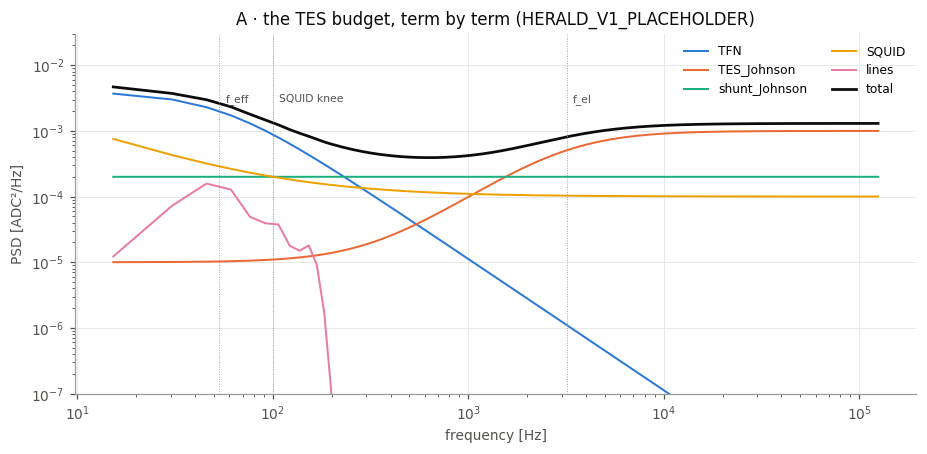

In [2]:
b = HERALD_V1_PLACEHOLDER
FS, N = 2.5e5, 16384
f = rfftfreq(N, d=1 / FS)
b_grid = b.on_grid(FS, N)                       # lines widened to ≥ one bin at fixed power (see A4)
comp = b_grid.component_psds(f)
print("provenance:", {k: v for k, v in b.provenance_record().items() if v != "placeholder"}, "… everything else: placeholder")
print(f"f_eff = {b.f_eff_hz:.1f} Hz (thermal, tau_eff = {b.tau_eff_s*1e3:.0f} ms)   f_el = {b.f_el_hz:.0f} Hz (electrical, tau_el = {b.tau_el_s*1e6:.0f} us)   SQUID knee = {b.squid_knee_hz:.0f} Hz")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for i, k in enumerate(["TFN", "TES_Johnson", "shunt_Johnson", "SQUID", "lines"]):
    ax.loglog(f[1:], comp[k][1:], color=PAL[i], label=k)
ax.loglog(f[1:], comp["total"][1:], color="#0b0b0b", lw=1.8, label="total")
for x, lab in [(b.f_eff_hz, "f_eff"), (b.f_el_hz, "f_el"), (b.squid_knee_hz, "SQUID knee")]:
    ax.axvline(x, color="#9a9a95", lw=0.6, ls=":"); ax.text(x * 1.08, comp["total"][1:].max() * 0.6, lab, fontsize=7, color="#52514e")
ax.set_ylim(1e-7, 3e-2); ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("PSD [ADC²/Hz]"); ax.set_title("A · the TES budget, term by term (HERALD_V1_PLACEHOLDER)")
ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()

### A1. Thermal-fluctuation noise (TFN) — *thermal, fundamental*

The TES is a tiny heat capacity connected to the bath through a weak thermal link. Energy crosses that link in
random packets (phonons), so the film's temperature — and therefore its resistance and current — fluctuates
even with nothing happening. This is the irreducible noise of a calorimeter. It is **white at the source**
but the TES only responds to temperature changes slower than its effective time constant, so what you read
out is a **low-pass**:

$$S_\text{TFN}(f) = \frac{S_\text{tfn}}{1 + (f/f_\text{eff})^2},\qquad f_\text{eff} = \frac{1}{2\pi\tau_\text{eff}}$$

Here $\tau_\text{eff}$ = 3 ms is the same time constant as the *signal's* decay — the pulse and this noise are
shaped by the same physics, which is why TFN is the term that ultimately limits energy resolution.
In the time domain it is slow, smooth wander with a correlation time of milliseconds.

### A2. TES Johnson noise — *electronic, with feedback*

Any resistor at temperature $T$ produces white voltage noise $4k_BTR$. The TES film is a resistor, but it sits
inside an electrothermal feedback loop: a current fluctuation heats the film, which raises its resistance,
which reduces the current. Below the loop's bandwidth the feedback cancels most of the Johnson noise; above it
the noise comes through untouched:

$$S_\text{TES}(f) = S_\text{tes}\,\frac{1/\mathcal{L}_I^2 + (f/f_\text{el})^2}{1 + (f/f_\text{el})^2}$$

with loop gain $\mathcal{L}_I$ = 10 (placeholder) and $f_\text{el}$ set by the 50 µs electrical time constant.
So it is *suppressed* at low frequency and *white* at high frequency — the mirror image of TFN. It is what
sets the noise floor between 3 kHz and 125 kHz in the plot.

### A3. Shunt Johnson and SQUID noise — *electronic, readout chain*

The shunt (load) resistor that voltage-biases the TES is another resistor: plain **white** noise, no feedback.
The SQUID amplifier adds a white floor plus a **1/f** term below its knee (100 Hz placeholder) — flux noise
from two-level systems in the SQUID's own materials, the same form the magnetic-calorimeter budget uses.
1/f noise looks like *drift*: long, slow excursions that never average out.

### A4. Lines — *environmental pickup*

Two kinds. **Mains**: 50 Hz and its harmonics, coupled through wiring and grounds — a pure tone. **Vibration /
microphonics**: the cryostat's mechanical resonances (tens of hertz) modulate the SQUID wiring; also tones.
On this grid they are all comfortably above the 15 Hz resolution, so they are *lines*. A tone narrower than one
bin, though, can fall between bins and vanish from a periodogram, so `on_grid()` widens each line to at least
one bin at fixed integrated power. And a tone *below two bins* — the ~1.4 Hz pulse-tube fundamental — is not a
line at all on a 65 ms record; it is slow drift, and belongs to `temporal_noise` (A6).

**Not in a TES budget:** the paramagnetic-spin term of the magnetic calorimeter (that is what
`AthermalNoiseBudget` has and this one deliberately does not).

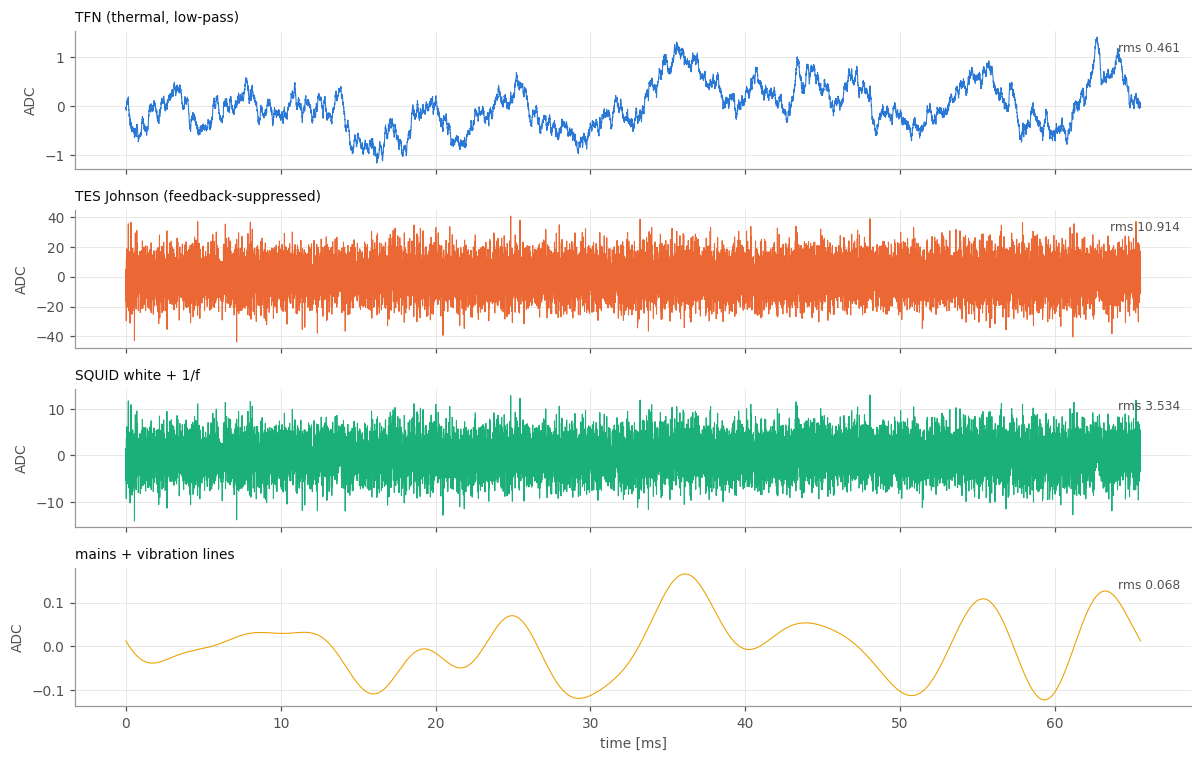

In [3]:
# What each term looks like in the time domain: generate each *alone* on the HeST grid.
def single_term(component_dicts, seed=0):
    cfg = dict(noise_type="composite", sampling_frequency=FS, noise_power=1.0, power_definition="variance",
               composite_psd_scaling="absolute", components=component_dicts)
    return NoiseGenerator(cfg, seed=seed).generate_noise(N)

parts = b_grid.to_component_dicts()
groups = {"TFN (thermal, low-pass)": [c for c in parts if c["name"] == "tfn"],
          "TES Johnson (feedback-suppressed)": [c for c in parts if c["name"].startswith("tes_johnson")],
          "SQUID white + 1/f": [c for c in parts if c["name"].startswith("squid")],
          "mains + vibration lines": [c for c in parts if c["name"].startswith("line")]}
t_ms = np.arange(N) / FS * 1e3
fig, ax = plt.subplots(4, 1, figsize=(11, 7), sharex=True)
for a, (name, comps), col in zip(ax, groups.items(), PAL):
    x = single_term(comps)
    a.plot(t_ms, x, color=col, lw=0.7); a.set_ylabel("ADC"); a.set_title(name, loc="left", fontsize=9)
    a.text(0.99, 0.85, f"rms {x.std():.3f}", transform=a.transAxes, ha="right", fontsize=8, color="#52514e")
ax[-1].set_xlabel("time [ms]"); plt.tight_layout()

Read top to bottom: TFN is smooth and slow (milliseconds); TES Johnson is fast grass with the low
frequencies missing; the SQUID trace is grass *plus* a slow wander that is the 1/f part; the lines are a
clean 50 Hz tone with a 100/150 Hz ripple and a 31/73 Hz vibration beat on top.

### A5. Between channels — bath, pickup, and what is private

HeRALD_v1 has 24 CPDs on **one cold stage**, read out through **one SQUID array / wiring loom**. That gives
three kinds of cross-channel structure, and `herald_simulation.noise.NoiseSpec` maps each onto a
`MultiChannelNoiseGenerator` mode:

| structure | physics | generator |
|---|---|---|
| **shared** | bath-temperature fluctuation seen by every TES; mains and vibration coupling into the common wiring | `shared_private` with `corr_strength` (default 0.3, placeholder) |
| **low-rank** | a few pickup *modes* (the loom, a ground loop) each coupling with its own sign and weight per channel | `lowrank` with `n_latent` modes |
| **private** | each TES's own TFN, Johnson and SQUID white noise | the private term in either mode |

The generator returns the covariance it *implied* and the one it *realised* in the draw; their ratio's
condition number κ is the honest measure of how well one record pins the structure down (≈1.2 here at
N/C = 683). One detail that matters for the experiment: the per-channel gains and mixing weights are drawn
**once per cell and frozen** (`freeze_channel_structure=True`), so every record of a cell shares one Σ̂.

shared_private ρ=0.3 (reference)   κ(implied vs realised) =  1.16   mean off-diag corr = +0.318
shared_private ρ=0.7 (bath ↑)      κ(implied vs realised) =  1.31   mean off-diag corr = +0.713
lowrank, 3 pickup modes            κ(implied vs realised) =  1.13   mean off-diag corr = -0.003


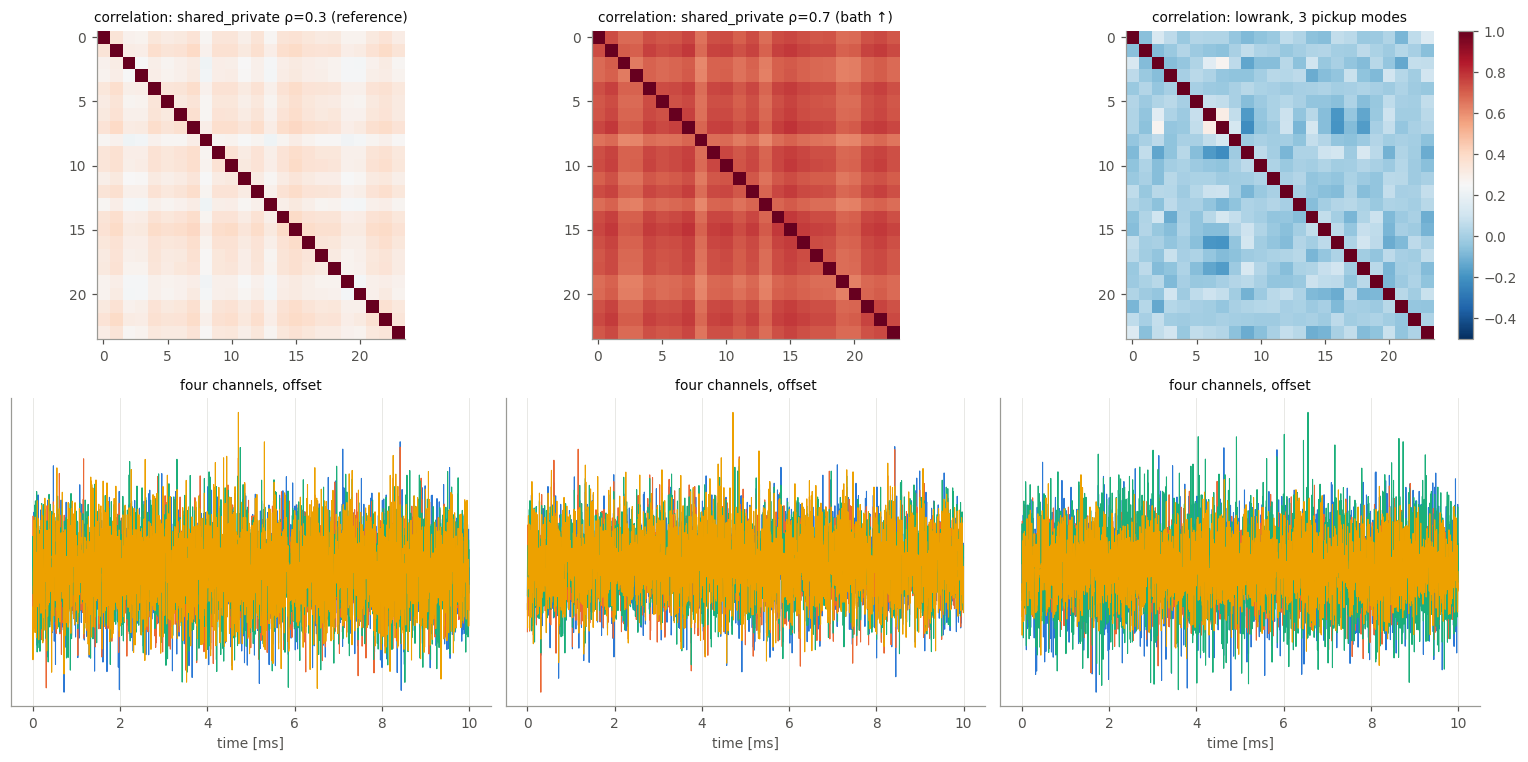

In [4]:
C = 24
def noise_block(spec, seed=0):
    gen = spec.generator(C, FS, N, structure_seed=11); gen.generate(8)
    gen.rng = np.random.default_rng([seed, 0x4E])
    return gen.generate(N, return_metadata=True)

specs = {"shared_private ρ=0.3 (reference)": hs.NoiseSpec(),
         "shared_private ρ=0.7 (bath ↑)": hs.NoiseSpec(corr_strength=0.7),
         "lowrank, 3 pickup modes": hs.NoiseSpec(mode="lowrank", n_latent=3)}
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for j, (name, spec) in enumerate(specs.items()):
    X, m = noise_block(spec)
    im = ax[0, j].imshow(np.corrcoef(X), vmin=-0.5, vmax=1, cmap="RdBu_r"); ax[0, j].set_title(f"correlation: {name}", fontsize=9); ax[0, j].grid(False)
    for c in range(4):
        ax[1, j].plot(t_ms[:2500], X[c, :2500] + 0.6 * c, color=PAL[c], lw=0.7)
    ax[1, j].set_yticks([]); ax[1, j].set_xlabel("time [ms]"); ax[1, j].set_title("four channels, offset", fontsize=9)
    print(f"{name:34s} κ(implied vs realised) = {np.linalg.cond(np.linalg.solve(m['implied_covariance'], m['realized_covariance'])):5.2f}   mean off-diag corr = {m['mean_offdiag_corr']:+.3f}")
plt.colorbar(im, ax=ax[0, 2], fraction=0.046); plt.tight_layout()

In the reference all 24 channels wiggle together a little (the common bath and the mains), each on its own
private grass. Raising the bath share to 0.7 makes them move almost in lock-step. The low-rank case is the
interesting one: its *mean* correlation is near zero because the pickup modes couple with random signs, yet
the matrix is plainly structured — pairs of channels are strongly correlated or anti-correlated. A model that
assumes "channels are independent" or "channels share one common mode" is wrong in different ways for these
two, which is exactly what a Σ-cell is designed to probe.

### A6. What the budget does not contain — and where it lives instead

* **Drift** below the resolution (pulse-tube, bath temperature over seconds): `noise_module.temporal_noise`,
  which modulates a stationary generator's level and shape over the record.
* **Sparse, non-Gaussian bursts** — the *low-energy excess* (LEE) that every cryogenic experiment sees, and
  glitches from mechanical relaxation: `noise_module.artifact_injector`, which adds declared transients. In the
  TESSERACT `pytessim` package this is "singles vs shared LEE"; in ORACLE it is an N-vs-U family, not part of Σ.
* **The signal-shaped part**: the TES's own responsivity roll-off applies to the *signal* too (the 50 µs rise
  / 3 ms decay of `QPSimulator`'s template) — that is why the budget's time constants are `design`, matched to
  the template, so noise and signal share one physics.

record 65.5 ms: bursts placed = 5 (expected 3.9), glitches placed = 2 (expected 2.0); std 12.515 -> 17.032


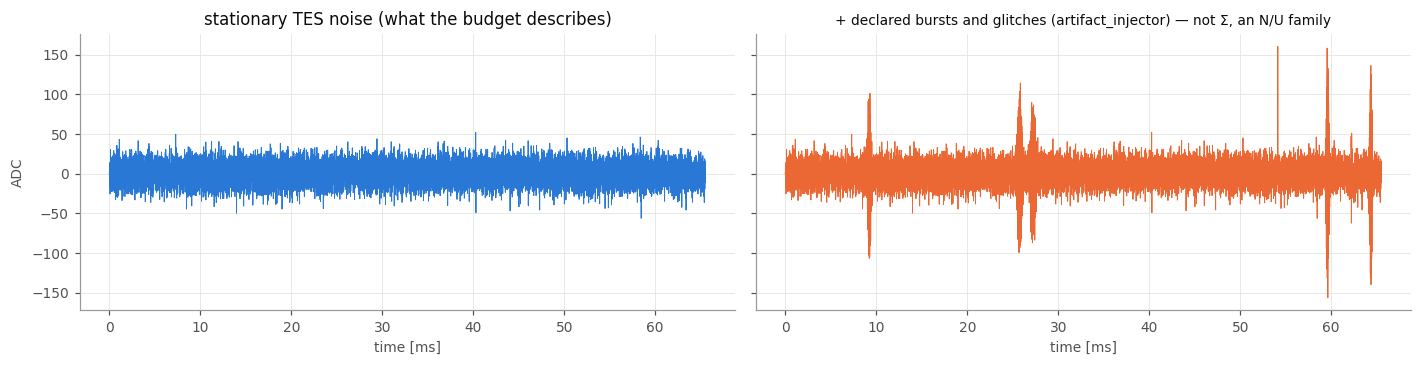

In [5]:
base = dict(noise_type="composite", sampling_frequency=FS, noise_power=1.0, power_definition="variance",
            composite_psd_scaling="absolute", components=parts)
stationary = NoiseGenerator(base, seed=3).generate_noise(N)
# amplitudes are ||artifact||_2 / baseline RMS ("rms_energy_ratio"), so a glitch of 8 is 8 sigma-equivalents of energy
inj = ArtifactInjector({"sampling_frequency": FS, "enable_bursts": True, "burst_rate": 60.0, "burst_amp_range": [30.0, 50.0],
                        "enable_glitches": True, "glitch_rate": 30.0, "glitch_amp_range": [8.0, 16.0],
                        "amplitude_unit": "rms_energy_ratio"}, seed=1)
with_art, art_meta = inj.apply(stationary, return_metadata=True)
n_b, n_g = art_meta["bursts"]["count"], art_meta["glitches"]["count"]
print(f"record {N / FS * 1e3:.1f} ms: bursts placed = {n_b} (expected {art_meta['bursts']['expected_count']:.1f}), "
      f"glitches placed = {n_g} (expected {art_meta['glitches']['expected_count']:.1f}); std {stationary.std():.3f} -> {with_art.std():.3f}")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4), sharey=True)
ax[0].plot(t_ms, stationary, color=PAL[0], lw=0.6); ax[0].set_title("stationary TES noise (what the budget describes)"); ax[0].set_xlabel("time [ms]"); ax[0].set_ylabel("ADC")
ax[1].plot(t_ms, with_art, color=PAL[1], lw=0.6); ax[1].set_title("+ declared bursts and glitches (artifact_injector) — not Σ, an N/U family", fontsize=9)
ax[1].set_xlabel("time [ms]"); plt.tight_layout()

---
## Part B — LUCiD: a photomultiplier and its front end

A water-Cherenkov PMT is a completely different instrument: it counts **photons**, one photoelectron at a
time, at gigahertz bandwidth. Its noise therefore has two layers, and only the first is inside LUCiD.

### B1. What LUCiD itself simulates — *photon-counting statistics*

| term | physics | where in LUCiD |
|---|---|---|
| **Quantum efficiency** | each photon is converted with probability QE (Bernoulli) — Poisson counting noise on the charge | `sensor_response.py`, per photon |
| **Single-photoelectron charge** | the dynode chain's gain fluctuates: a Gaussian core plus an exponential low-charge tail (Bellamy 1994) | `digitizer._sample_spe_charge`, SK / HK fits |
| **Transit-time spread** | electrons take different paths to the anode: Gaussian jitter on every photon's arrival (σ ≈ 1 ns) | `build_make_hits_waveform(tts_sigma_ns=1.0)` |
| **Dark noise** | thermionic emission from the photocathode: uncorrelated 1 pe pulses at ~4 kHz per PMT | `digitizer.generate_dark_noise` (production path) |
| **Time jitter / TDC** | SK- or HK-style charge-dependent timing resolution and 0.4 ns quantisation | `digitizer._sample_time_jitter` |

Every one of these is **independent per photon and per PMT**. There is no electronics model — no amplifier,
no cable, no digitiser noise — and no covariance between channels anywhere. LUCiD's waveform is a
photoelectron histogram, not a voltage.

/tmp/claude-0/-home-claude/15017658-0894-552d-b60b-c9837edcd9c5/scratchpad/lucid/LUCiD/lucid/overlap.py:160: DeprecationWarning: backend and device argument on jit is deprecated. You can use `jax.device_put(..., jax.local_devices(backend="cpu")[0])` on the inputs to the jitted function to get the same behavior.
  @partial(jax.jit, device=jax.devices('cpu')[0])
/tmp/claude-0/-home-claude/15017658-0894-552d-b60b-c9837edcd9c5/scratchpad/lucid/LUCiD/lucid/propagation/cylinder.py:530: DeprecationWarning: backend and device argument on jit is deprecated. You can use `jax.device_put(..., jax.local_devices(backend="cpu")[0])` on the inputs to the jitted function to get the same behavior.
  @partial(jax.jit, static_argnums=(2, 3, 4, 5, 6), device=jax.devices('cpu')[0])
/tmp/claude-0/-home-claude/15017658-0894-552d-b60b-c9837edcd9c5/scratchpad/lucid/LUCiD/lucid/propagation/sphere.py:326: DeprecationWarning: backend and device argument on jit is deprecated. You can use `jax.device_put(..., jax.lo

dark pulses in 100 µs over 200 PMTs: 90 (expected ≈ 84.0 )


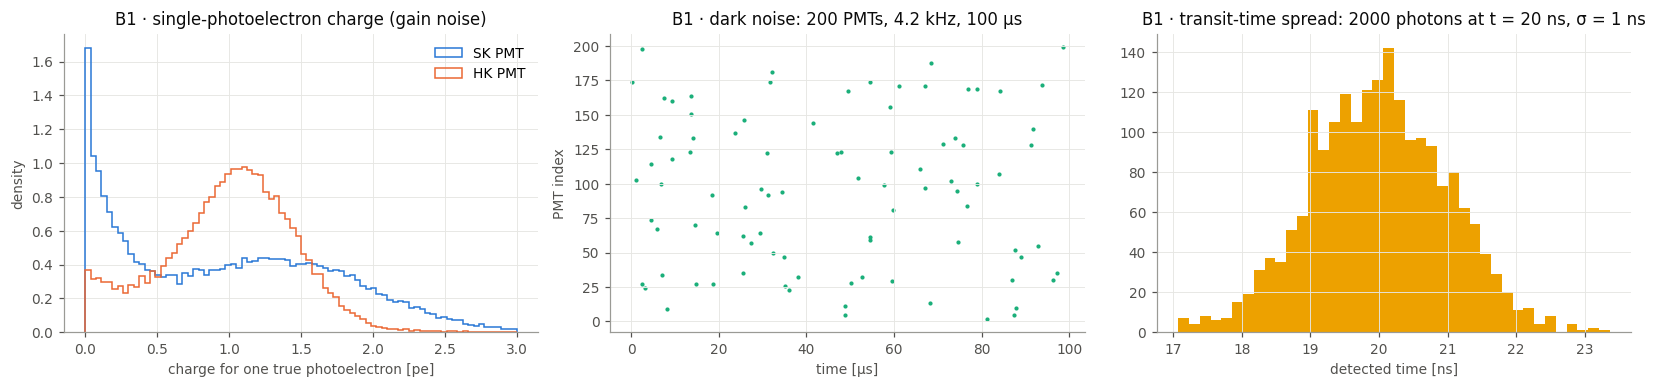

In [6]:
import jax
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator
from lucid.sources import isotropic_source
import importlib.util
_spec = importlib.util.spec_from_file_location("lucid_digitizer", LUCID / "lucid" / "simulation" / "digitizer.py")
dig = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(dig)      # standalone NumPy module: load it directly

rng = np.random.default_rng(0)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
# SPE charge distribution (1 pe true) for the SK and HK fits
for i, (lab, spe) in enumerate([("SK PMT", dig._SPE_SK), ("HK PMT", dig._SPE_HK)]):
    q = dig._sample_spe_charge(np.ones(40000), spe, rng)
    ax[0].hist(q, bins=80, range=(0, 3), histtype="step", color=PAL[i], label=lab, density=True)
ax[0].set_xlabel("charge for one true photoelectron [pe]"); ax[0].set_ylabel("density"); ax[0].set_title("B1 · single-photoelectron charge (gain noise)"); ax[0].legend(frameon=False)
# dark noise: independent Poisson pulses per PMT
dn = dig.generate_dark_noise(n_sensors=200, rate_khz=4.2, t_start_ns=0.0, t_end_ns=1e5, rng=rng)
dn = dn if isinstance(dn, tuple) else (dn,)
idx, t = np.asarray(dn[0]), np.asarray(dn[1]) if len(dn) > 1 else None
ax[1].scatter(t / 1e3 if t is not None else np.zeros_like(idx), idx, s=3, color=PAL[2]); ax[1].set_xlabel("time [µs]"); ax[1].set_ylabel("PMT index"); ax[1].set_title("B1 · dark noise: 200 PMTs, 4.2 kHz, 100 µs")
# TTS: the same arrival time smeared per photon
arr = np.zeros(2000) + 20.0; sm = arr + rng.normal(0, 1.0, size=arr.size)
ax[2].hist(sm, bins=40, color=PAL[3]); ax[2].set_xlabel("detected time [ns]"); ax[2].set_title("B1 · transit-time spread: 2000 photons at t = 20 ns, σ = 1 ns")
plt.tight_layout()
print("dark pulses in 100 µs over 200 PMTs:", len(idx), "(expected ≈", round(200 * 4.2e3 * 1e-4, 1), ")")

### B2. What LUCiD does not simulate — *the front end* — and how the notebook adds it

Between the anode and the waveform sits an amplifier, a cable, and a 1 GHz digitiser. That is where the
*electronic* and *environmental* noise of a Cherenkov detector lives, and it is what `noise_module` supplies.
The record is LUCiD's: **1 ns bins over 512 ns**, so the resolution is **1.95 MHz** and Nyquist is 500 MHz.
That single number decides what can be modelled:

| term | physics | representable on 512 ns? | component |
|---|---|---|---|
| **amplifier white floor** | thermal + shot noise of the front-end transistor, referred to input | yes — dominant | `white` |
| **front-end bandwidth** | the amplifier/cable low-pass, ~250 MHz | yes | `rolloff` (lowpass) |
| **flicker (1/f)** | transistor 1/f; only ~2 decades in band | weakly | `powerlaw −1` |
| **clock / switching pickup** | the ADC clock and DC-DC converters and their harmonics, tens of MHz | **yes — the real coherent line source** | `line` |
| **cable-reflection ringing** | impedance mismatch → a damped resonance ~150 MHz | yes | `resonance` |
| **50 Hz mains** | the loudest line in the TES record | **no** — 2.6 × 10⁻⁵ of one bin | — |
| **drift, 1/f below MHz** | | no — needs a longer `window_ns` or decimation | `temporal_noise`, `psd_resampling` |

Units first: LUCiD's bin holds photoelectrons. A PSD in pe²/Hz means nothing physically, so the notebook
convolves each PMT's histogram with a **single-photoelectron voltage template** (2 ns rise, 8 ns fall, 4 mV per
pe) before adding noise in mV. The noise level (0.8 mV rms) is a placeholder like the TES numbers.

50 Hz on this grid: 2.5600000000000002e-05 of one bin — not representable; the first line the record can hold is at 1.9531249999999998 MHz


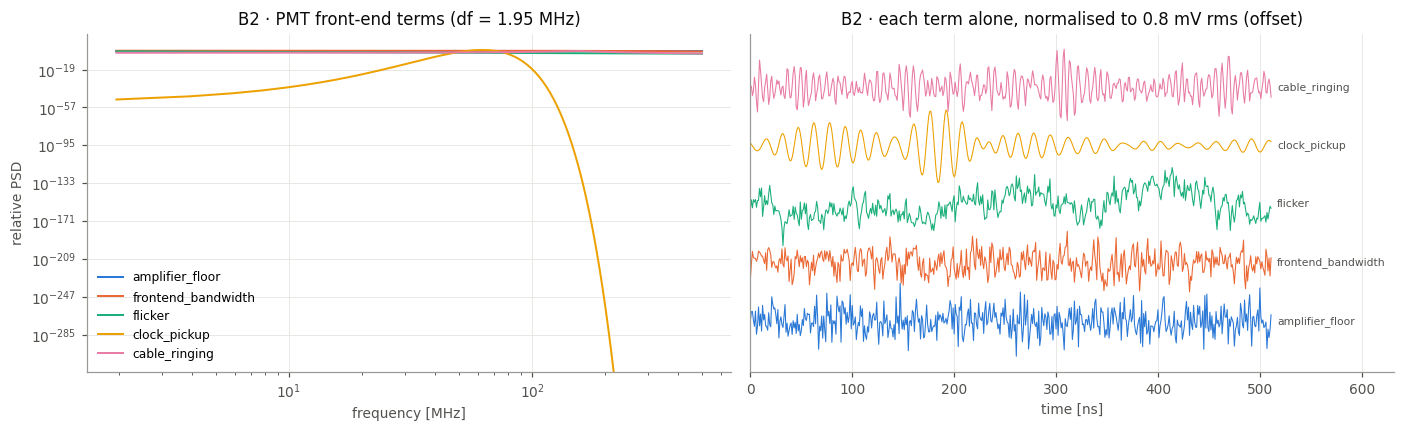

In [7]:
FS_L, N_L = 1e9, 512
fL = rfftfreq(N_L, d=1 / FS_L)
PMT_FRONTEND_V1 = dict(
    noise_type="composite", sampling_frequency=FS_L, noise_power=0.8 ** 2, power_definition="variance", composite_psd_scaling="normalize",
    components=[
        {"type": "white",     "scale": 1.0,  "name": "amplifier_floor"},
        {"type": "rolloff",   "scale": 1.0,  "corner_hz": 2.5e8, "order": 2.0, "kind": "lowpass", "name": "frontend_bandwidth"},
        {"type": "powerlaw",  "scale": 0.05, "exponent": -1.0, "reference_hz": 1e7, "name": "flicker"},
        {"type": "line",      "scale": 6.0,  "frequency_hz": 6.25e7, "width_hz": 4e6, "name": "clock_pickup"},
        {"type": "resonance", "scale": 0.5,  "center_hz": 1.5e8, "half_width_hz": 2e7, "name": "cable_ringing"},
    ])
g = NoiseGenerator(PMT_FRONTEND_V1, seed=0)
_, S_total, meta = g.build_psd_density(N_L, return_metadata=True)
# component spectra, drawn one at a time (density normalisation, absolute so shapes are comparable)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, c in enumerate(PMT_FRONTEND_V1["components"]):
    _, S_c = NoiseGenerator({**PMT_FRONTEND_V1, "composite_psd_scaling": "absolute", "components": [c]}).build_psd_density(N_L)
    ax[0].loglog(fL[1:] / 1e6, S_c[1:], color=PAL[i], label=c["name"])
ax[0].set_xlabel("frequency [MHz]"); ax[0].set_ylabel("relative PSD"); ax[0].set_title("B2 · PMT front-end terms (df = 1.95 MHz)"); ax[0].legend(frameon=False, fontsize=8)
tns = np.arange(N_L)
for i, c in enumerate(PMT_FRONTEND_V1["components"]):
    x = NoiseGenerator({**PMT_FRONTEND_V1, "components": [c]}, seed=i).generate_noise(N_L)
    ax[1].plot(tns, x + 4 * i, color=PAL[i], lw=0.7)
    ax[1].text(N_L + 5, 4 * i, c["name"], fontsize=7, color="#52514e", va="center")
ax[1].set_xlim(0, N_L + 120); ax[1].set_yticks([]); ax[1].set_xlabel("time [ns]"); ax[1].set_title("B2 · each term alone, normalised to 0.8 mV rms (offset)")
plt.tight_layout()
print("50 Hz on this grid:", 50 / fL[1], "of one bin — not representable; the first line the record can hold is at", fL[1] / 1e6, "MHz")

What the time-domain panel shows: the white floor is featureless grass; the band-limited term is the same
grass with the sharpest wiggles removed (nothing faster than ~4 ns survives the 250 MHz roll-off); flicker on
a 512 ns record is nearly indistinguishable from white — there is not enough record for 1/f to develop; the
clock pickup is a clean 16 ns sinusoid (62.5 MHz); the cable ringing is a decaying 6.7 ns oscillation that
keeps restarting.

### B3. Between channels — crates, not cold stages

Coherent noise in a PMT array comes from **shared electronics**: PMTs on the same HV supply, front-end
board or digitiser crate share the same clock pickup and ripple. So the natural covariance unit is the
*crate* (or string), not the whole detector: 16–64 channels, `shared_private` within a crate, independent
across crates. The dark noise, by contrast, is independent per PMT — a Poisson process, not a covariance.

The estimator warning from the arms plan is concrete here: with 64 channels and only 512 samples, N/C = 8,
and the realised covariance of a matched cell already has κ ≈ 5–7 against its own implied one (≈ 25 once the
channels are strongly coherent, because the common mode then dominates a badly estimated matrix). To *measure* a
covariance change on a PMT array you must lengthen the window (`window_ns` ≥ 16–32 µs) or the alarm reads
the estimator's noise, not the detector's.

same crate, 32 768-sample window (32.8 µs, N/C = 512): κ floor = 1.31


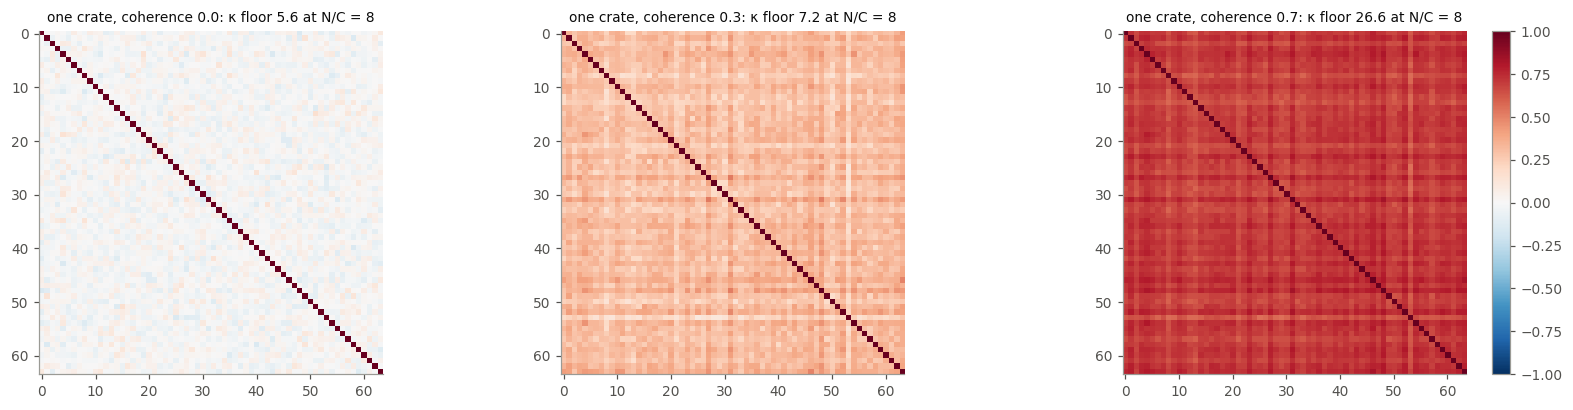

In [8]:
GROUP = 64
def crate(corr, seed=0, n=N_L):
    gen = MultiChannelNoiseGenerator(PMT_FRONTEND_V1, {"mode": "shared_private", "n_channels": GROUP, "corr_strength": corr,
                                                       "freeze_channel_structure": True, "normalize_channel_variance": False}, seed=seed)
    return gen.generate(n, return_metadata=True)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for j, corr in enumerate([0.0, 0.3, 0.7]):
    X, m = crate(corr)
    im = ax[j].imshow(np.corrcoef(X), vmin=-1, vmax=1, cmap="RdBu_r"); ax[j].grid(False)
    k = np.linalg.cond(np.linalg.solve(m["implied_covariance"], m["realized_covariance"]))
    ax[j].set_title(f"one crate, coherence {corr}: κ floor {k:.1f} at N/C = 8", fontsize=9)
plt.colorbar(im, ax=ax[2], fraction=0.046); plt.tight_layout()
X_long, m_long = crate(0.3, n=32768)
print("same crate, 32 768-sample window (32.8 µs, N/C = 512): κ floor =", round(np.linalg.cond(np.linalg.solve(m_long['implied_covariance'], m_long['realized_covariance'])), 2))

### B4. The digitiser contract — the alias fold

One acquisition-side change is unique to a sampled system: **decimation without an anti-alias filter**.
If a 1 GHz stream is read out at 250 MHz by keeping every fourth sample, everything above 125 MHz — the
cable ring, the top of the amplifier band — folds back into the passband. Nothing was added; the *contract*
changed. `noise_module.psd_resampling.alias_fold_psd_density` gives the folded spectrum in closed form,
which makes this the cleanest N family there is: the prediction is exact.

decimated ensemble PSD / closed-form fold: median ratio = 0.99 (1.00 = exact prediction); in-band power before = 0.227, after fold = 0.640 mV²


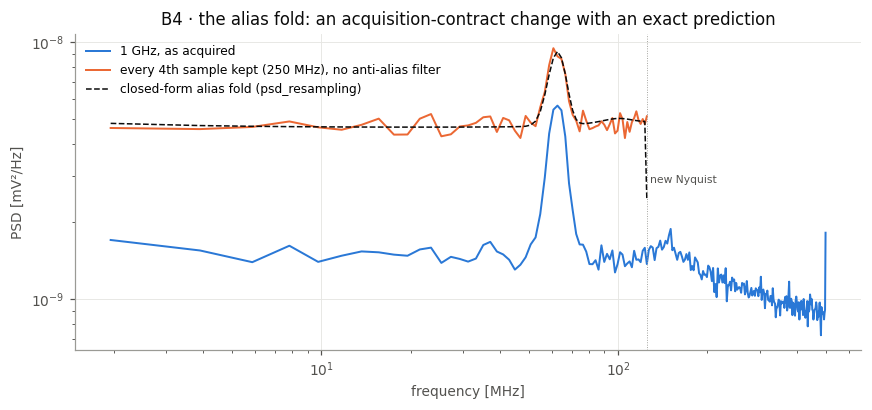

In [9]:
x = NoiseGenerator(PMT_FRONTEND_V1, seed=5).generate_ensemble(256, N_L)              # 256 random triggers
psd_1g = np.mean(np.abs(rfft(x, axis=-1)) ** 2, axis=0) * 2 / (FS_L * N_L)
xd = x[:, ::4]; fD = rfftfreq(xd.shape[1], d=4 / FS_L)
psd_dec = np.mean(np.abs(rfft(xd, axis=-1)) ** 2, axis=0) * 2 / (FS_L / 4 * xd.shape[1])
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.loglog(fL[1:] / 1e6, psd_1g[1:], color=PAL[0], label="1 GHz, as acquired")
ax.loglog(fD[1:] / 1e6, psd_dec[1:], color=PAL[1], label="every 4th sample kept (250 MHz), no anti-alias filter")
# closed form: fold the generator's own target density (fL, S_total) into the 250 MHz Nyquist band
ff, Sf, fold_meta = alias_fold_psd_density(fL, S_total, FS_L / 4, xd.shape[1])
level = psd_1g[1:].mean() / S_total[1:].mean()          # S_total is the design density; the ensemble sets the absolute level
ax.loglog(ff[1:] / 1e6, Sf[1:] * level, color="#0b0b0b", lw=1.0, ls="--", label="closed-form alias fold (psd_resampling)")
ratio = np.median(psd_dec[1:] / (np.interp(fD, ff, Sf)[1:] * level))
print(f"decimated ensemble PSD / closed-form fold: median ratio = {ratio:.2f} (1.00 = exact prediction); "
      f"in-band power before = {np.trapezoid(psd_1g[fL <= FS_L / 8], fL[fL <= FS_L / 8]):.3f}, after fold = {np.trapezoid(psd_dec, fD):.3f} mV²")
ax.axvline(125, color="#9a9a95", lw=0.6, ls=":"); ax.text(128, psd_1g[1:].max() * 0.5, "new Nyquist", fontsize=7, color="#52514e")
ax.set_xlabel("frequency [MHz]"); ax.set_ylabel("PSD [mV²/Hz]"); ax.set_title("B4 · the alias fold: an acquisition-contract change with an exact prediction"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout()

---
## The two detectors side by side

| noise class | physical origin | HeRALD (TES @ 250 kHz, 65 ms) | Cherenkov PMT (@ 1 GHz, 512 ns) | simulated by |
|---|---|---|---|---|
| **thermal, fundamental** | energy exchange with the bath | TFN — dominant, low-pass at 1/2πτ_eff | (amplifier thermal noise is folded into the white floor) | `TESNoiseBudget` / `white` |
| **electronic, resistive** | Johnson noise of resistors | TES Johnson (feedback-suppressed), shunt Johnson | amplifier white floor | `white`, `rolloff` |
| **electronic, amplifier** | SQUID flux noise / transistor 1/f | SQUID white + 1/f, knee ~100 Hz | flicker — barely in band | `white` + `powerlaw −1` |
| **bandwidth** | readout time constants | responsivity roll-off (also shapes the signal) | front-end low-pass ~250 MHz | `rolloff` |
| **environmental lines** | mains, vibration, clocks | 50 Hz + harmonics, 31/73 Hz microphonics — **in band** | ADC clock/switching at tens of MHz; 50 Hz **not representable** | `line`, `resonance` |
| **shared between channels** | common cold stage / wiring; common crate / HV | bath fluctuation, loom pickup — `shared_private`, `lowrank` | crate coherence — `shared_private` per 16–64 PMTs | `MultiChannelNoiseGenerator` |
| **counting statistics** | quantisation of the signal carrier | (quasiparticle Poisson statistics are in HeST's transport) | QE Bernoulli, SPE gain, TTS, dark counts — **inside LUCiD** | HeST / LUCiD |
| **non-stationary, sparse** | LEE bursts, glitches, drift | `artifact_injector`, `temporal_noise` (declared families, not Σ) | glitches; drift only with a long window | `noise_module` |
| **background** | real unwanted events | radioactivity, LEE as *events* | dark counts as *events*, radioactivity | simulated as events, never as noise |

Two things the table makes visible. First, the *same* module serves both detectors because the spectral
components are physics-agnostic; only the presets differ — a TES budget on the left, a PMT front end on the
right. Second, the **record length** decides what noise exists at all: the loudest line in one detector is
literally unrepresentable in the other. Any claim about "correlated noise" has to say on which grid.